# Subglacial hydrology of a Greenland outlet glacier

Water at the base of glaciers and ice sheets profoundly influences how fast ice flows.
In Greenland, surface melt drains through moulins to the bed, pressurising the subglacial drainage system and modulating sliding speeds on diurnal-to-seasonal timescales.

In this tutorial we will:

1. Introduce the equations governing **distributed (sheet) drainage** — the linked-cavity system.
2. Build a synthetic outlet-glacier geometry and set up a sheet-only hydrology model.
3. Run the model to steady state under low uniform basal melt.
4. Show that the full coupled sheet–channel model (GlaDS) produces the same result when melt is low — channels don't matter yet.

The model we use is **GlaDS** (Glacier Drainage System model; Werder et al., 2013), which couples a distributed linked-cavity *sheet* to discrete Röthlisberger *channels* on the mesh edges.
hydropack implements GlaDS with Firedrake finite elements and exposes each constitutive relation as a swappable function, so you can easily test alternative physics.

In this first tutorial we focus entirely on the **sheet** (inefficient drainage). In the [next tutorial](02-channels.ipynb) we introduce the channel equations and show how channelisation emerges at higher melt rates.

## The distributed sheet equations

The distributed drainage system is a thin water film — a *sheet* — that occupies cavities between the ice and the bedrock.
These cavities open by basal sliding over bedrock bumps and close by viscous creep of the ice.
The key unknowns are:

* **Hydraulic potential** $\phi(x,y,t)$ — the energy per unit volume of water, which drives flow.
* **Sheet thickness** $h(x,y,t)$ — the gap between ice and bed occupied by water.

### Water balance (the $\phi$ equation)

Conservation of water mass gives the elliptic PDE for $\phi$:

$$\nabla \cdot \mathbf{q} = w - v + m$$

where $m$ is the melt rate (source), and $w$ and $v$ are the cavity opening and closing rates.
The **sheet flux** follows a nonlinear Darcy-type law:

$$\mathbf{q} = -k\, h^\alpha\, |\nabla\phi|^{\beta - 2}\, \nabla\phi$$

with exponents $\alpha = 5/4$ and $\beta = 3/2$.  This is a turbulent flow law — the flux depends on the square root of the pressure gradient, not linearly.

### Cavity geometry (the $h$ equation)

The sheet thickness evolves as a balance between opening and closing:

$$\frac{\partial h}{\partial t} = w - v$$

**Opening** by sliding over bumps of height $h_r$ spaced $l_r$ apart:

$$w = \frac{u_b\,(h_r - h)}{l_r} \quad \text{when } h < h_r$$

**Closing** by ice creep under the effective pressure $N = \phi_0 - \phi$ (the difference between ice overburden and water pressure):

$$v = \frac{2A}{n^n}\, h\, N^3$$

where $A$ is Glen's flow-rate factor and $n = 3$ is the Glen exponent.

At steady state, $w = v$: the cavity maintains a thickness where sliding exactly balances creep closure.  High $N$ (well-drained bed) gives small cavities; low $N$ (high water pressure) gives large cavities.

### Boundary condition

At the glacier terminus, water exits at atmospheric pressure: $\phi = \phi_m = \rho_w g B$.

## Geometry

Our outlet glacier is 20 km long and 5 km wide, resting on a flat bed.
The ice surface follows a square-root profile typical of ice sheets controlled by plastic yielding:

$$S(x) = 6\left(\sqrt{x + 5000} - \sqrt{5000}\right) + 1 \quad \text{[m]}$$

giving about 1 m of ice at the terminus ($x = 0$) and ~450 m at the ice divide ($x = 20$ km).
This is a representative scale for a Greenland outlet glacier tongue — large enough to develop interesting drainage structure, small enough to solve quickly.

Water exits the glacier at the terminus where the hydraulic potential equals the bed-elevation potential (atmospheric pressure at the bed).

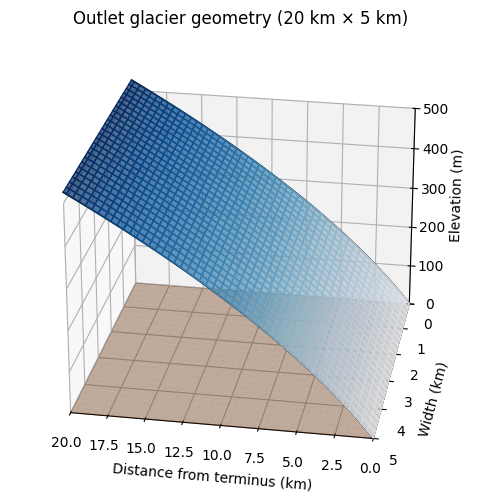

In [6]:
import firedrake as fd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

from hydropack.constants import ice_density, water_density, gravity

# Domain: a 20 km × 5 km outlet glacier tongue
Lx, Ly = 20e3, 5e3
nx, ny = 40, 10

mesh = fd.RectangleMesh(nx, ny, Lx, Ly)
Q = fd.FunctionSpace(mesh, "CG", 1)
x, y = fd.SpatialCoordinate(mesh)

# Ice surface, bed, and thickness
surface = fd.interpolate(6 * (fd.sqrt(x + 5000) - fd.sqrt(5000.0)) + 1, Q)
bed = fd.interpolate(fd.Constant(0.0), Q)
H = surface - bed

# 3D surface plot of the glacier geometry
xs = np.linspace(0, Lx, 100)
ys = np.linspace(0, Ly, 25)
X, Y = np.meshgrid(xs, ys)
S_grid = 6 * (np.sqrt(X + 5000) - np.sqrt(5000)) + 1
B_grid = np.zeros_like(X)

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection="3d")

# Bed surface
ax.plot_surface(X / 1e3, Y / 1e3, B_grid, color="saddlebrown",
                alpha=0.4, zorder=1)

# Ice surface coloured by thickness
colors = cm.Blues((S_grid - S_grid.min()) / (S_grid.max() - S_grid.min()))
ax.plot_surface(X / 1e3, Y / 1e3, S_grid, facecolors=colors,
                alpha=0.7, shade=True, zorder=2)

# Outline at y = 0 and y = Ly for cross-section context
for yi in [0, Ly]:
    Si = 6 * (np.sqrt(xs + 5000) - np.sqrt(5000)) + 1
    ax.plot(xs / 1e3, np.full_like(xs, yi / 1e3), Si,
            "k-", lw=1.2, zorder=3)

ax.set_xlabel("Distance from terminus (km)")
ax.set_ylabel("Width (km)")
ax.set_zlabel("Elevation (m)")
ax.set_title("Outlet glacier geometry (20 km × 5 km)")
ax.view_init(elev=25, azim=100)
ax.set_xlim(0, 20)
ax.set_ylim(0, 5)
ax.set_zlim(0, 500);

## Setting up a sheet-only model

For the sheet-only solve, we disable channel evolution by passing a custom `S_ode_coefficients` function that always returns zeros — the channel area $S$ stays at its initial value (effectively zero) and contributes nothing to the water balance.

This demonstrates hydropack's swappable physics: any constitutive relation can be replaced at construction time without editing the solver code.

In [7]:
import numpy as np
from hydropack.models.subglacialhydrology import SubglacialHydrologyModel

CR = fd.FunctionSpace(mesh, "CR", 1)
V = fd.VectorFunctionSpace(mesh, "CG", 1)

# Pressure fields
p_i = fd.interpolate(fd.Constant(ice_density * gravity) * H, Q)
phi_m = fd.interpolate(fd.Constant(water_density * gravity) * bed, Q)
phi_0 = fd.interpolate(p_i + phi_m, Q)

# Basal sliding speed (uniform ~1 µm/s ≈ 30 m/yr)
u_b = fd.Function(Q).interpolate(fd.Constant(1e-6))

# Initial conditions
h_init = fd.interpolate(fd.Constant(0.0001), Q)
S_init = fd.interpolate(fd.Constant(0.0), CR)     # no initial channels
phi_init = fd.Function(Q).interpolate(phi_0)       # start at overburden (N = 0)

# Melt rate (will be set per experiment)
m = fd.Function(Q)
m.assign(0.0)

# Dirichlet BC: phi = phi_m at terminus (x = 0, boundary id 1)
bc = fd.DirichletBC(Q, phi_m, 1)


# Custom S ODE that prevents channel evolution (returns zero coefficients)
def no_channel_evolution(S_cur, S_old, phi_s, h_cr, N_cr, pw_s, **kwargs):
    """Disable channel evolution: dS/dt = 0."""
    return np.zeros_like(S_cur), np.zeros_like(S_cur)


# Sheet-only model: channels are present in the mesh but never grow
model_sheet = SubglacialHydrologyModel(
    mesh,
    thickness=H,
    bed=bed,
    sliding_speed=u_b,
    melt_rate=m,
    phi_init=phi_init,
    h_init=h_init,
    S_init=S_init,
    phi_m=phi_m,
    p_i=p_i,
    phi_0=phi_0,
    dirichlet_bcs=[bc],
    S_ode_coefficients=no_channel_evolution,   # <-- disable channels
)

print(f"Sheet-only model created: {mesh.num_vertices()} nodes, "
      f"{mesh.num_cells()} elements")

Sheet-only model created: 451 nodes, 800 elements


## Running to steady state

The simulation loop alternates between solving the hydraulic potential $\phi$ (an elliptic PDE) and advancing the sheet thickness $h$ and channel area $S$ (implicit ODEs).
This operator-split step is wrapped in `model.step(dt)`.

We advance the model until the relative change in $\phi$, $N$, $h$, and $S$ all drop below a tolerance.
We start with a low uniform melt rate ($m = 7.93 \times 10^{-11}$ m/s ≈ 2.5 mm/yr) to establish the baseline drainage structure.

In [8]:
def advance_to_steady(model, dt, melt_rate, *, rel_tol=5e-4,
                      max_steps=5000, check_every=6, ramp_steps=50):
    """Run the model to steady state with a gradual recharge ramp."""
    # Use smaller dt during ramp to help Newton converge
    dt_ramp = min(dt, 3600.0)
    for frac in [0.01, 0.02, 0.05, 0.1, 0.2, 0.35, 0.5, 0.75, 1.0]:
        model.m.interpolate(fd.Constant(frac * melt_rate))
        for _ in range(ramp_steps):
            model.step(dt_ramp)
        model.update_phi()

    model.m.interpolate(fd.Constant(melt_rate))

    # Convergence snapshots
    phi_prev = fd.Function(model.U).interpolate(model.phi)
    N_prev = fd.Function(model.U).interpolate(model.N)
    h_prev = fd.Function(model.U).interpolate(model.h)
    S_prev = fd.Function(model.CR).interpolate(model.S)

    for k in range(1, max_steps + 1):
        model.step(dt)

        if k % check_every == 0:
            model.update_phi()
            rphi = float(fd.norm(model.phi - phi_prev) / (fd.norm(model.phi) + 1e-30))
            rN = float(fd.norm(model.N - N_prev) / (fd.norm(model.N) + 1e-30))
            rh = float(fd.norm(model.h - h_prev) / (fd.norm(model.h) + 1e-30))
            rS = float(fd.norm(model.S - S_prev) / (fd.norm(model.S) + 1e-30))

            phi_prev.assign(model.phi)
            N_prev.assign(model.N)
            h_prev.assign(model.h)
            S_prev.assign(model.S)

            sim_days = k * dt / 86400
            if k % (check_every * 50) == 0:
                print(f"  day {sim_days:.0f}: rphi={rphi:.2e} rN={rN:.2e} rh={rh:.2e} rS={rS:.2e}")

            if rphi < rel_tol and rN < rel_tol and rh < rel_tol and rS < rel_tol:
                print(f"  Converged at day {sim_days:.0f} (step {k})")
                return k

    print(f"  WARNING: did not converge in {max_steps} steps")
    return max_steps

In [9]:
dt = 14400  # 4-hour timestep (implicit solvers are unconditionally stable)

# Low uniform melt rate
melt_low = 7.93e-11  # m/s (low uniform melt)

print("Running sheet-only model to steady state...")
advance_to_steady(model_sheet, dt, melt_low)

Running sheet-only model to steady state...


/home/andrew/venv-firedrake/lib/python3.10/site-packages/firedrake/interpolation.py:391: FutureWarning: The use of `interpolate` to perform the numerical interpolation is deprecated.
This feature will be removed very shortly.

Instead, import `interpolate` from the `firedrake.__future__` module to update
the interpolation's behaviour to return the symbolic `ufl.Interpolate` object associated
with this interpolation.

You can then assemble the resulting object to get the interpolated quantity
of interest. For example,

```
from firedrake.__future__ import interpolate
...

assemble(interpolate(expr, V))
```

Alternatively, you can also perform other symbolic operations on the interpolation operator, such as taking
the derivative, and then assemble the resulting form.

  warnings.warn("""The use of `interpolate` to perform the numerical interpolation is deprecated.
/home/andrew/venv-firedrake/lib/python3.10/site-packages/firedrake/interpolation.py:391: FutureWarning: The use of `interpola

  day 50: rphi=5.88e-04 rN=1.10e-08 rh=1.81e-03 rS=0.00e+00
  Converged at day 78 (step 468)


468

This simulation will take some time. This is a great time to take a break and go for a walk.

### Visualising the steady state

The key diagnostic is the **effective pressure** $N = \phi_0 - \phi$, which is the difference between ice overburden and water pressure.
High $N$ means low water pressure (the bed is well-drained); low or negative $N$ means the water pressure approaches or exceeds ice overburden.

Under low melt, the drainage is entirely through the distributed cavity sheet — no channels develop.
$N$ increases monotonically from the terminus (where the BC forces $\phi = \phi_m$) to the ice divide.

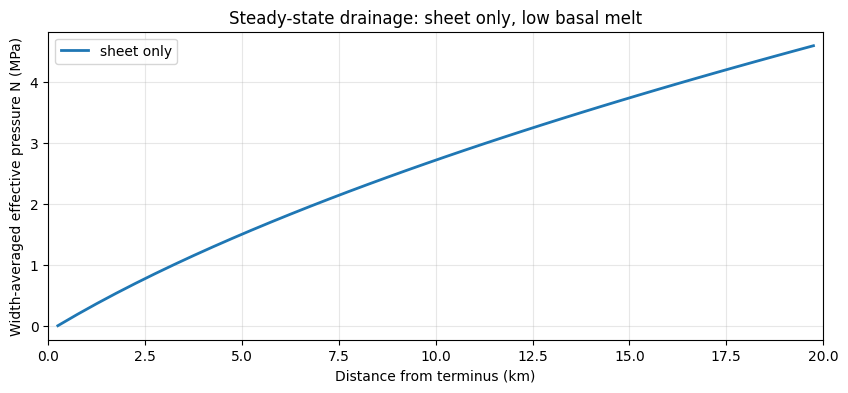

In [10]:
def width_averaged_Nx(model, Lx=20e3, nbins=40):
    """Compute width-averaged effective pressure N(x)."""
    coords = model.mesh.coordinates.dat.data_ro
    x = coords[:, 0]
    Nvals = model.N.dat.data_ro
    bins = np.linspace(0, Lx, nbins + 1)
    idx = np.digitize(x, bins) - 1
    Nx = np.zeros(nbins)
    count = np.zeros(nbins, dtype=int)
    for i, val in zip(idx, Nvals):
        if 0 <= i < nbins:
            Nx[i] += val
            count[i] += 1
    mask = count > 0
    Nx[mask] /= count[mask]
    xc = 0.5 * (bins[:-1] + bins[1:])
    return xc, Nx

model_sheet.update_phi()
xc_sheet, Nx_sheet = width_averaged_Nx(model_sheet)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(xc_sheet / 1e3, Nx_sheet / 1e6, "C0-", lw=2, label="sheet only")
ax.set_xlabel("Distance from terminus (km)")
ax.set_ylabel("Width-averaged effective pressure N (MPa)")
ax.set_title("Steady-state drainage: sheet only, low basal melt")
ax.set_xlim(0, 20)
ax.legend()
ax.grid(True, alpha=0.3);

## Sheet-only vs full GlaDS

Now let's verify that when melt is low, enabling channels makes no difference.
We create the same model but with the default (full GlaDS) physics — channels are allowed to evolve — and run to steady state under the same low melt rate.

In [11]:
# Full model (channels enabled — the default)
h_init_full = fd.interpolate(fd.Constant(0.0001), Q)
S_init_full = fd.interpolate(fd.Constant(0.001), CR)
phi_init_full = fd.Function(Q).interpolate(phi_0)
m_full = fd.Function(Q); m_full.assign(0.0)

model_full = SubglacialHydrologyModel(
    mesh,
    thickness=H,
    bed=bed,
    sliding_speed=u_b,
    melt_rate=m_full,
    phi_init=phi_init_full,
    h_init=h_init_full,
    S_init=S_init_full,
    phi_m=phi_m,
    p_i=p_i,
    phi_0=phi_0,
    dirichlet_bcs=[fd.DirichletBC(Q, phi_m, 1)],
    # No S_ode_coefficients override → channels can evolve
)

print("Running full GlaDS model (with channels) to steady state...")
advance_to_steady(model_full, dt, melt_low)

Running full GlaDS model (with channels) to steady state...
  day 50: rphi=5.84e-04 rN=1.09e-08 rh=1.81e-03 rS=2.11e-04
  Converged at day 78 (step 468)


468

### Comparing the two solutions

If the sheet-only and full GlaDS solutions match, it confirms that under low melt the channels are irrelevant — the sheet handles all the drainage.
This is the expected result: channel formation requires enough energy dissipation to melt ice walls faster than creep closure can shut them, and at low melt rates the fluxes are far too small.

Max |N_sheet - N_full| = 0.0 Pa (0.00% of N_max)


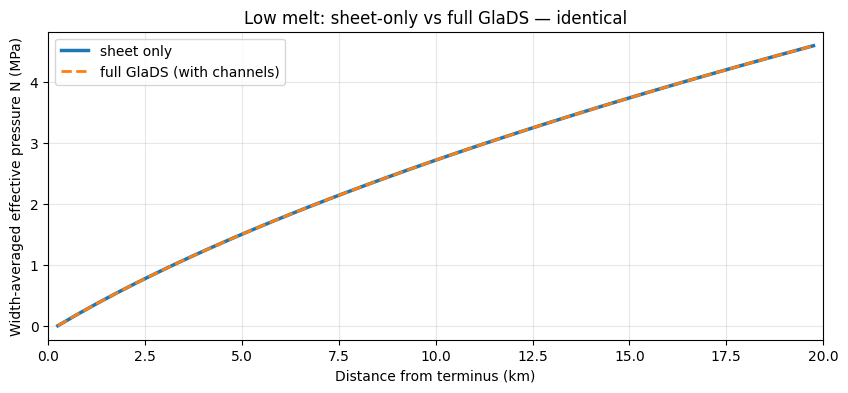

In [12]:
model_full.update_phi()
xc_full, Nx_full = width_averaged_Nx(model_full)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(xc_sheet / 1e3, Nx_sheet / 1e6, "C0-", lw=2.5, label="sheet only")
ax.plot(xc_full / 1e3, Nx_full / 1e6, "C1--", lw=2.0, label="full GlaDS (with channels)")
ax.set_xlabel("Distance from terminus (km)")
ax.set_ylabel("Width-averaged effective pressure N (MPa)")
ax.set_title("Low melt: sheet-only vs full GlaDS — identical")
ax.set_xlim(0, 20)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Quantify the difference
diff = np.abs(Nx_sheet - Nx_full)
print(f"Max |N_sheet - N_full| = {diff.max():.1f} Pa "
      f"({diff.max() / max(Nx_sheet.max(), 1) * 100:.2f}% of N_max)")

## Conclusion

Under low uniform melt, the subglacial drainage system is entirely governed by the **distributed sheet** — the linked-cavity system described by the equations above.
Channels are present in the model but contribute nothing: there isn't enough energy dissipation to grow them.

The sheet-only and full GlaDS solutions are identical, confirming that for this regime the simpler sheet equations are sufficient.

But what happens when melt increases — during a Greenland summer, for example?
As more water enters the system, fluxes grow, dissipation increases, and at some threshold the energy released by turbulent flow is enough to melt channels into the ice base.
These channels create an **efficient** drainage pathway that fundamentally changes the pressure distribution.

In the [next tutorial](02-channels.ipynb) we introduce the channel equations and show how the drainage system transitions from sheet-dominated to channel-dominated as melt intensity increases.